In [20]:
import pandas as pd

db = pd.read_csv("data_ml.csv")

print(db.shape)
print(db.head())
print(db.info())
print(db.describe())

(59461, 28)
          id                          url   brand model  price currency  \
0  103638249  https://999.md/ro/103638249  Nissan  Juke   8900      EUR   
1  105026245  https://999.md/ro/105026245  Nissan  Juke   7799      EUR   
2  104981896  https://999.md/ro/104981896  Nissan  Juke  16700      EUR   
3  104939877  https://999.md/ro/104939877  Nissan  Juke   7799      EUR   
4  104528276  https://999.md/ro/104528276  Nissan  Juke   4000      EUR   

            generation  year  mileage  engine  ...  \
0      I (2010 - 2019)  2018   195000     1.5  ...   
1      I (2010 - 2019)  2013   239000     1.5  ...   
2  II (2019 - prezent)  2023     3710     1.6  ...   
3      I (2010 - 2019)  2014   192000     1.6  ...   
4      I (2010 - 2019)  2014    88000     1.5  ...   

                      scraped_at horsepower offer_type      seller_type  \
0  2026-09-05 15:02:42.904834+00        NaN       Vând      Dealer auto   
1   2026-09-05 14:19:29.86651+00        NaN       Vând      De

In [3]:
missing = db.isnull().sum()
print(missing)

id                           0
url                          0
brand                        0
model                        0
price                        0
currency                     0
generation                  62
year                         0
mileage                      0
engine                     183
fuel_type                    0
gearbox                      6
state                        0
registration_country         0
drivetrain                   1
body_type                    0
doors                     2669
seats                        6
scraped_at                   0
horsepower               23172
offer_type                   0
seller_type                  7
original_price               0
original_currency            0
price_eur                    0
mileage_was_corrected        0
class                     3651
Score                        0
dtype: int64


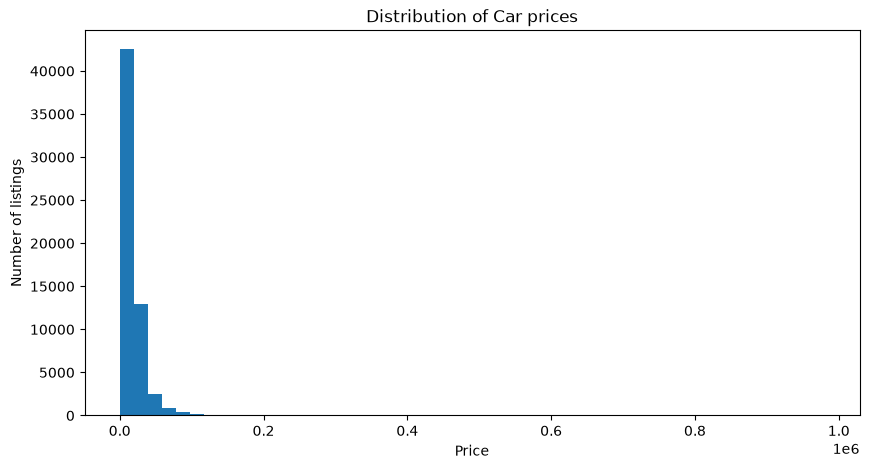

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(db["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of listings")
plt.title("Distribution of Car prices")
plt.show()

In [15]:
db.corr(numeric_only=True)["price"].sort_values()

mileage                 -0.402561
Score                   -0.181579
mileage_was_corrected   -0.079465
id                      -0.046189
doors                   -0.008252
horsepower              -0.004712
seats                    0.077210
engine                   0.401770
year                     0.451763
price_eur                0.905218
price                    1.000000
original_price           1.000000
Name: price, dtype: float64

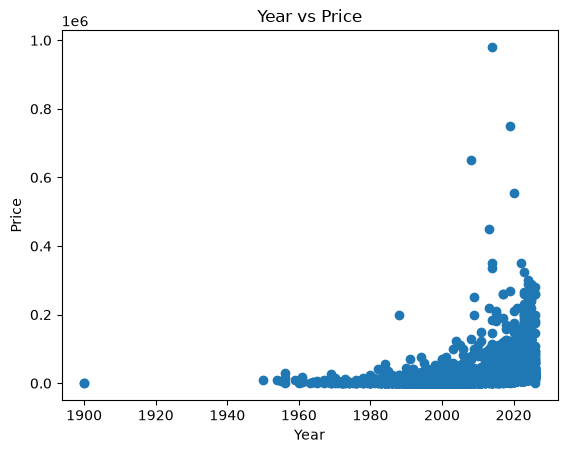

In [16]:
plt.scatter(db["year"], db["price"])
plt.xlabel("Year")
plt.ylabel("Price")
plt.title("Year vs Price")
plt.show()

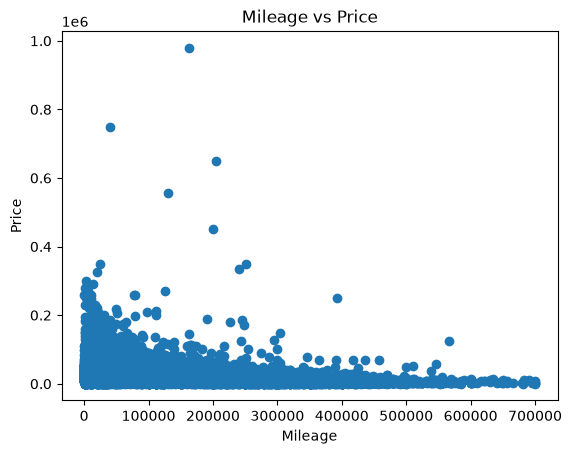

In [17]:
plt.scatter(db["mileage"], db["price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()


In [18]:
db.groupby("brand")["price"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False)

,count,mean,median
brand,,,
BMW,7166,26950.342171,21999.0
Mercedes,5543,23944.049973,18500.0
Volkswagen,4514,10166.100576,9000.0
Toyota,4321,14470.758852,10499.0
Renault,4311,8934.984458,8999.0
...,...,...,...
Cenntro,1,6000.000000,6000.0
Haima,1,3700.000000,3700.0
Aston Martin,1,59900.000000,59900.0


In [34]:
from sklearn.model_selection import train_test_split

X = db.drop(columns=["price", "id", "url", "currency", "original_currency", "original_price", "price_eur"])
y = db["price_eur"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (47568, 21)
Testing: (11893, 21)


In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical:", list(numerical_columns))
print("Categorical:", list(categorical_columns))

Numerical: ['year', 'mileage', 'engine', 'doors', 'seats', 'horsepower', 'Score']
Categorical: ['brand', 'model', 'generation', 'fuel_type', 'gearbox', 'state', 'registration_country', 'drivetrain', 'body_type', 'scraped_at', 'offer_type', 'seller_type', 'class']


/var/folders/vr/57hhm5n12cq1fw072pwq5w300000gn/T/ipykernel_42840/731612521.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = X.select_dtypes(


Random Forest

In [29]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['brand','model','generation',...,'mileage_was_corrected','class','Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [31]:
y_pred = pipeline.predict(X_test)
print(y_pred[:10])

[12098.74       27644.62333333 31407.67       32280.36333333
  1343.50509824  8931.59666667  8455.77        9426.17
 53301.29666667 26969.54      ]


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 1503.3756994090627
RMSE: 4176.650292120159
R²: 0.9348900563307203


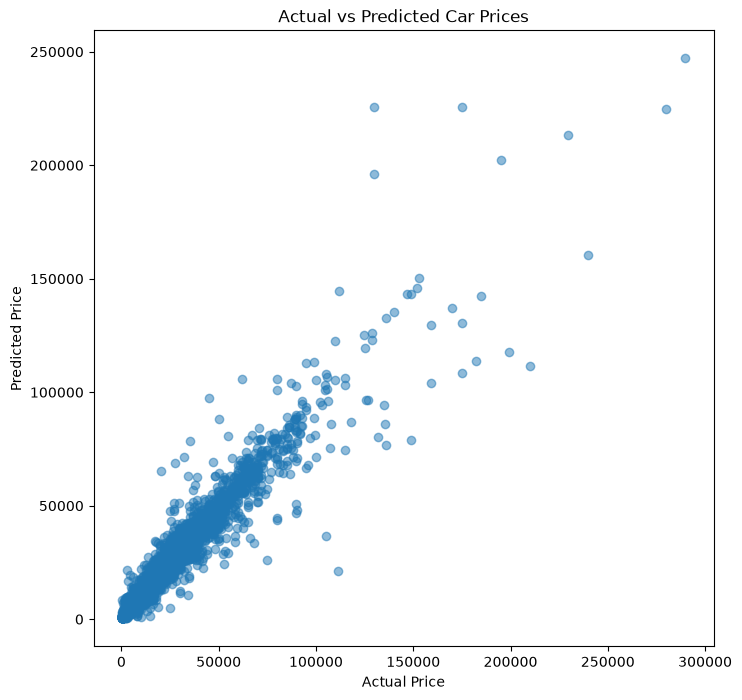

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()